# NextTick - Phase 2: Baseline Models

| Task | Baseline Model |
|---|---|
| Classification (UP/DOWN direction) | Logistic Regression |
| Regression (% magnitude of change) | Linear Regression |

## Key methodology

- **Chronological train/test split** (80/20) - never random, always time-ordered
- **StandardScaler** fit on training data only, applied to both train and test
- **TimeSeriesSplit cross-validation** - not standard k-fold - to respect chronological order
- **Class imbalance handling** via `class_weight='balanced'` in Logistic Regression

## Reference baselines
- **Naive classifier:** predict UP every day -> 55.47% accuracy. Our model must beat this.
- **Naive regressor:** predict the mean daily return -> any positive predictive power is a win.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score,
)

# Set plotting defaults
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Imports successful")

Imports successful


## 2. Load the Dataset

Load `nexttick_dataset.csv` produced by Phase 1. Convert the `Date` column back into a proper DatetimeIndex so we can sort chronologically.

In [2]:
# Load the processed dataset from Phase 1
df = pd.read_csv(
    "../data/processed/nexttick_dataset.csv",
    index_col="Date",
    parse_dates=True,
)

# Sort chronologically within each ticker, then by date globally
df = df.sort_index()

print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min().date()} → {df.index.max().date()}")
print(f"Tickers: {df['ticker'].unique().tolist()}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 3 rows:")
df.head(3)

Shape: (12350, 14)
Date range: 2021-05-18 → 2026-04-17
Tickers: ['AAPL', 'GOOGL', 'AMZN', 'TSLA', 'JPM', 'MSFT', 'GS', 'JNJ', 'XOM', 'BAC']

Columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'daily_return', 'sma_10', 'sma_20', 'volatility_10', 'momentum_10', 'rsi_14', 'target_return', 'target_direction', 'ticker']

First 3 rows:


,Close,High,Low,Open,Volume,daily_return,sma_10,sma_20,volatility_10,momentum_10,rsi_14,target_return,target_direction,ticker
Date,,,,,,,,,,,,,,
2021-05-18,121.809906,123.897796,121.741611,123.478267,63342900,-0.011246,123.583902,126.454548,0.016407,-0.021806,28.148518,-0.001282,0,AAPL
2021-05-18,112.196182,114.438158,112.182297,114.173840,22204000,-0.011556,113.189088,114.086675,0.017060,-0.019230,36.214772,0.003991,1,GOOGL
2021-05-18,161.613998,165.600006,161.518494,164.628998,56568000,-0.011653,161.609500,165.639651,0.016780,-0.024032,30.503986,-0.000149,0,AMZN


## 3. Select Features and Targets

We use the 6 engineered features as predictors. The raw OHLCV columns (Open, High, Low, Close, Volume) are excluded from modeling, they carry ticker-specific price levels (AAPL at $200 vs BAC at $40) which would dominate the model's attention without being informative. The engineered features are already *scale-invariant* (returns, ratios, bounded indicators), which makes them comparable across tickers.

In [3]:
# Features: the 6 engineered technical indicators
FEATURE_COLS = [
    "daily_return",
    "sma_10",
    "sma_20",
    "volatility_10",
    "momentum_10",
    "rsi_14",
]

# Two targets: one per task
CLASSIFICATION_TARGET = "target_direction"
REGRESSION_TARGET = "target_return"

X = df[FEATURE_COLS].copy()
y_clf = df[CLASSIFICATION_TARGET].copy()
y_reg = df[REGRESSION_TARGET].copy()

print(f"X shape: {X.shape}")
print(f"y_clf shape: {y_clf.shape} (classification target)")
print(f"y_reg shape: {y_reg.shape} (regression target)")
print(f"\nX summary:")
X.describe()

X shape: (12350, 6)
y_clf shape: (12350,) (classification target)
y_reg shape: (12350,) (regression target)

X summary:


,daily_return,sma_10,sma_20,volatility_10,momentum_10,rsi_14
count,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000
mean,0.000793,206.379285,205.740904,0.017521,0.007686,52.770011
std,0.020177,139.530628,138.727546,0.010020,0.064056,12.347279
min,-0.154262,24.406934,24.763288,0.002846,-0.349899,14.934517
25%,-0.008741,119.594862,120.046728,0.010880,-0.027327,43.798919
50%,0.000753,167.317615,166.450562,0.014994,0.007494,52.880414
75%,0.010557,269.666319,267.857809,0.020952,0.042743,61.803722
max,0.226900,943.342426,938.417844,0.093775,0.480459,94.195258


## 4. Chronological Train/Test Split

We use an **80/20 chronological split** - first 80% of dates for training, last 20% for testing.

Because our dataset contains multiple tickers, we sort by date first, then cut. This means the train set ends at some date, and the test set covers the most recent ~year across all tickers. 

In [4]:
# Find the cutoff date: 80% through the sorted date range
unique_dates = df.index.unique().sort_values()
cutoff_idx = int(len(unique_dates) * 0.8)
cutoff_date = unique_dates[cutoff_idx]

print(f"Total unique dates: {len(unique_dates)}")
print(f"Cutoff date: {cutoff_date.date()}")

# Build masks
train_mask = df.index <  cutoff_date
test_mask  = df.index >= cutoff_date

X_train, X_test = X[train_mask], X[test_mask]
y_clf_train, y_clf_test = y_clf[train_mask], y_clf[test_mask]
y_reg_train, y_reg_test = y_reg[train_mask], y_reg[test_mask]

print(f"\nTrain set: {len(X_train):,} rows ({train_mask.sum()/len(df)*100:.1f}%)")
print(f"Test set:  {len(X_test):,} rows ({test_mask.sum()/len(df)*100:.1f}%)")
print(f"\nTrain date range: {X_train.index.min().date()} -> {X_train.index.max().date()}")
print(f"Test date range:  {X_test.index.min().date()} -> {X_test.index.max().date()}")
print(f"\nTrain UP rate: {y_clf_train.mean():.3f}")
print(f"Test UP rate:  {y_clf_test.mean():.3f}")

Total unique dates: 1235
Cutoff date: 2025-04-24

Train set: 9,880 rows (80.0%)
Test set:  2,470 rows (20.0%)

Train date range: 2021-05-18 -> 2025-04-23
Test date range:  2025-04-24 -> 2026-04-17

Train UP rate: 0.516
Test UP rate:  0.555


### Visualizing the chronological split

Before training, visualize the split to confirm it's truly chronological - training data entirely precedes test data, with no overlap.

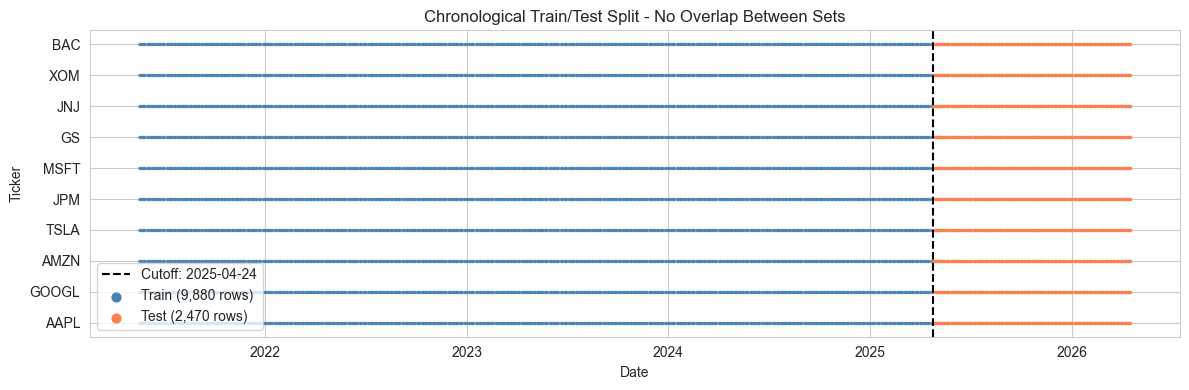

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))

# Plot one line per ticker, colored by train/test
for ticker in df["ticker"].unique():
    ticker_df = df[df["ticker"] == ticker]
    train_dates = ticker_df.index[ticker_df.index < cutoff_date]
    test_dates  = ticker_df.index[ticker_df.index >= cutoff_date]
    
    ax.scatter(train_dates, [ticker] * len(train_dates), s=2, c="steelblue", alpha=0.5)
    ax.scatter(test_dates,  [ticker] * len(test_dates),  s=2, c="coral",     alpha=0.7)

# Cutoff line
ax.axvline(cutoff_date, color="black", linestyle="--", linewidth=1.5, label=f"Cutoff: {cutoff_date.date()}")

# Legend entries
ax.scatter([], [], c="steelblue", s=40, label=f"Train ({len(X_train):,} rows)")
ax.scatter([], [], c="coral",     s=40, label=f"Test ({len(X_test):,} rows)")

ax.set_xlabel("Date")
ax.set_ylabel("Ticker")
ax.set_title("Chronological Train/Test Split - No Overlap Between Sets")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

## Establishing Naive Baselines

Before training any real model, compute the **naive baselines** for each task. Any real model must beat these to be considered useful.

- **Classification naive baseline:** always predict UP (the majority class)
- **Regression naive baseline:** always predict zero (the overwhelming central tendency of daily returns)

These numbers go into our comparison table as the "must-beat" reference points.

In [6]:
# Naive classification baseline: always predict UP 
naive_clf_preds = np.ones_like(y_clf_test)  # predict 1 (UP) for every test sample

naive_clf_acc = accuracy_score(y_clf_test, naive_clf_preds)
naive_clf_f1  = f1_score(y_clf_test, naive_clf_preds, average="macro")

print("Naive classification baseline: always predict UP")
print(f"  Accuracy:  {naive_clf_acc:.4f}")
print(f"  Macro F1:  {naive_clf_f1:.4f}")
print(f"  This is the accuracy our real classifier must beat.")

# Naive regression baseline: always predict 0
naive_reg_preds = np.zeros_like(y_reg_test)

naive_reg_mae  = mean_absolute_error(y_reg_test, naive_reg_preds)
naive_reg_rmse = np.sqrt(mean_squared_error(y_reg_test, naive_reg_preds))

print("\nNaive regression baseline: always predict 0")
print(f"  MAE:   {naive_reg_mae:.6f}")
print(f"  RMSE:  {naive_reg_rmse:.6f}")
print(f"  Our real regressor must achieve LOWER MAE and RMSE than this.")

Naive classification baseline: always predict UP
  Accuracy:  0.5547
  Macro F1:  0.3568
  This is the accuracy our real classifier must beat.

Naive regression baseline: always predict 0
  MAE:   0.012338
  RMSE:  0.017514
  Our real regressor must achieve LOWER MAE and RMSE than this.


## 5. Feature Scaling

Fit StandardScaler on the **training set only**, then transform both train and test sets using the training-derived mean and std. 

In [7]:
scaler = StandardScaler()
scaler.fit(X_train)  # learn mean and std from training data ONLY

X_train_scaled = pd.DataFrame(
    scaler.transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)

print("After scaling:")
print(f"  Train feature means (should be ~0): {X_train_scaled.mean().abs().max():.4f}")
print(f"  Train feature stds  (should be ~1): {X_train_scaled.std().round(3).tolist()}")
print(f"  Test  feature means (can differ from 0): {X_test_scaled.mean().round(3).tolist()}")

After scaling:
  Train feature means (should be ~0): 0.0000
  Train feature stds  (should be ~1): [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
  Test  feature means (can differ from 0): [0.059, 1.045, 1.034, -0.2, 0.181, 0.334]


## 6. Logistic Regression (Classification Baseline)

Logistic Regression models the probability of "UP" as a logistic function of a linear combination of features. It's the simplest binary classifier and the standard baseline for any binary task.

### Key configuration
- **`class_weight='balanced'`** - automatically upweights the minority class (DOWN) to counter the UP-majority imbalance. Without this, the model would be tempted to default toward predicting UP.
- **`max_iter=1000`** - ensures convergence on our scaled features.
- **`random_state=42`** - reproducibility.

In [8]:
# Fit Logistic Regression on the training set
logreg = LogisticRegression(
    class_weight="balanced",  # counter UP/DOWN imbalance
    max_iter=1000,
    random_state=42,
)
logreg.fit(X_train_scaled, y_clf_train)

# Predict on the test set
logreg_preds  = logreg.predict(X_test_scaled)
logreg_probs  = logreg.predict_proba(X_test_scaled)[:, 1]  # P(UP)

# Metrics
logreg_acc   = accuracy_score(y_clf_test, logreg_preds)
logreg_prec  = precision_score(y_clf_test, logreg_preds)
logreg_rec   = recall_score(y_clf_test, logreg_preds)
logreg_f1    = f1_score(y_clf_test, logreg_preds, average="macro")

print("Logistic Regression — Test Set Performance")
print(f"  Accuracy:   {logreg_acc:.4f}   (naive baseline: 0.5547)")
print(f"  Precision:  {logreg_prec:.4f}")
print(f"  Recall:     {logreg_rec:.4f}")
print(f"  Macro F1:   {logreg_f1:.4f}   (naive baseline: 0.3568)")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_clf_test, logreg_preds)
print(pd.DataFrame(
    cm,
    index=["actual DOWN", "actual UP"],
    columns=["pred DOWN", "pred UP"],
))

print("\nClassification Report:")
print(classification_report(y_clf_test, logreg_preds, target_names=["DOWN", "UP"]))

Logistic Regression — Test Set Performance
  Accuracy:   0.5049   (naive baseline: 0.5547)
  Precision:  0.5686
  Recall:     0.4445
  Macro F1:   0.5048   (naive baseline: 0.3568)

Confusion Matrix:
             pred DOWN  pred UP
actual DOWN        638      462
actual UP          761      609

Classification Report:
              precision    recall  f1-score   support

        DOWN       0.46      0.58      0.51      1100
          UP       0.57      0.44      0.50      1370

    accuracy                           0.50      2470
   macro avg       0.51      0.51      0.50      2470
weighted avg       0.52      0.50      0.50      2470



### Confusion matrix heatmap

The confusion matrix shows four numbers: correct DOWN predictions, correct UP predictions, and the two error types. A balanced model spreads its errors roughly equally; a model that exploits class imbalance shows lopsided errors.

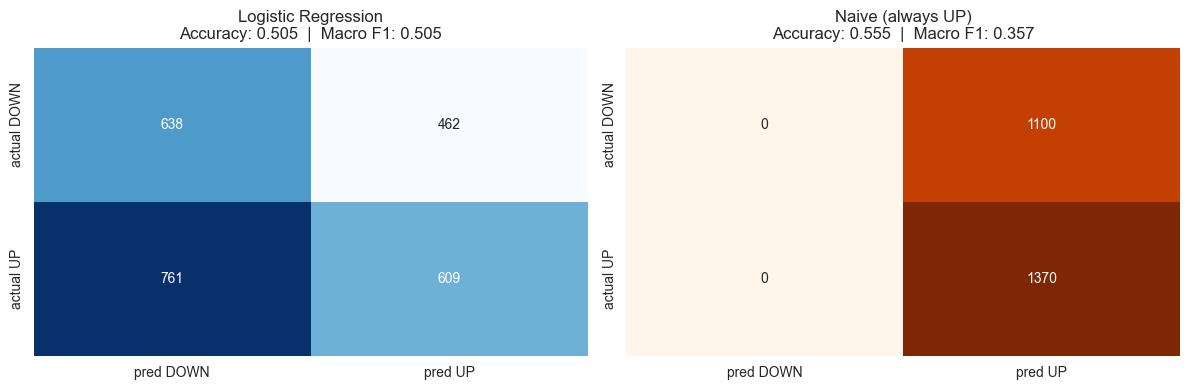

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: our Logistic Regression
cm_logreg = confusion_matrix(y_clf_test, logreg_preds)
sns.heatmap(
    cm_logreg, annot=True, fmt="d", cmap="Blues",
    xticklabels=["pred DOWN", "pred UP"],
    yticklabels=["actual DOWN", "actual UP"],
    ax=axes[0], cbar=False,
)
axes[0].set_title(f"Logistic Regression\nAccuracy: {logreg_acc:.3f}  |  Macro F1: {logreg_f1:.3f}")

# Right: naive "always predict UP" for contrast
cm_naive = confusion_matrix(y_clf_test, naive_clf_preds)
sns.heatmap(
    cm_naive, annot=True, fmt="d", cmap="Oranges",
    xticklabels=["pred DOWN", "pred UP"],
    yticklabels=["actual DOWN", "actual UP"],
    ax=axes[1], cbar=False,
)
axes[1].set_title(f"Naive (always UP)\nAccuracy: {naive_clf_acc:.3f}  |  Macro F1: {naive_clf_f1:.3f}")

plt.tight_layout()
plt.show()

## 7. Linear Regression (Regression Baseline)

Linear Regression predicts `target_return` (tomorrow's % change) as a linear combination of the 6 scaled features.

### Metrics
- **MAE** (Mean Absolute Error) - average absolute difference between prediction and truth. 
- **RMSE** (Root Mean Squared Error) - penalizes large errors more heavily. Always ≥ MAE.
- **R²** - fraction of target variance explained by the model. Can be negative if the model is worse than predicting the mean.

In [10]:
# Fit Linear Regression on the training set
linreg = LinearRegression()
linreg.fit(X_train_scaled, y_reg_train)

# Predict on the test set
linreg_preds = linreg.predict(X_test_scaled)

# Metrics
linreg_mae  = mean_absolute_error(y_reg_test, linreg_preds)
linreg_rmse = np.sqrt(mean_squared_error(y_reg_test, linreg_preds))
linreg_r2   = r2_score(y_reg_test, linreg_preds)

print("Linear Regression — Test Set Performance")
print(f"  MAE:   {linreg_mae:.6f}   (naive baseline: 0.012338)")
print(f"  RMSE:  {linreg_rmse:.6f}   (naive baseline: 0.017514)")
print(f"  R²:    {linreg_r2:.6f}")

print("\nPrediction statistics:")
print(f"  Predicted return — min:    {linreg_preds.min():+.6f}")
print(f"  Predicted return — max:    {linreg_preds.max():+.6f}")
print(f"  Predicted return — mean:   {linreg_preds.mean():+.6f}")
print(f"  Predicted return — std:    {linreg_preds.std():.6f}")
print(f"  Actual return    — std:    {y_reg_test.std():.6f}")

print("\nFeature coefficients (scaled features):")
coef_df = pd.DataFrame({
    "feature":     FEATURE_COLS,
    "coefficient": linreg.coef_,
}).sort_values("coefficient", key=abs, ascending=False)
print(coef_df.to_string(index=False))

Linear Regression — Test Set Performance
  MAE:   0.012318   (naive baseline: 0.012338)
  RMSE:  0.017495   (naive baseline: 0.017514)
  R²:    -0.006990

Prediction statistics:
  Predicted return — min:    -0.002417
  Predicted return — max:    +0.001838
  Predicted return — mean:   +0.000173
  Predicted return — std:    0.000641
  Actual return    — std:    0.017438

Feature coefficients (scaled features):
      feature  coefficient
       sma_10    -0.003558
       sma_20     0.003278
       rsi_14    -0.000292
  momentum_10     0.000250
volatility_10     0.000167
 daily_return     0.000114


### Predicted vs actual return scatter

A model that's learning to predict will show predictions spread across a similar range as the actual returns. A model defaulted to predicting near-zero will show a horizontal band of predictions near y=0 regardless of the true value on the x-axis.

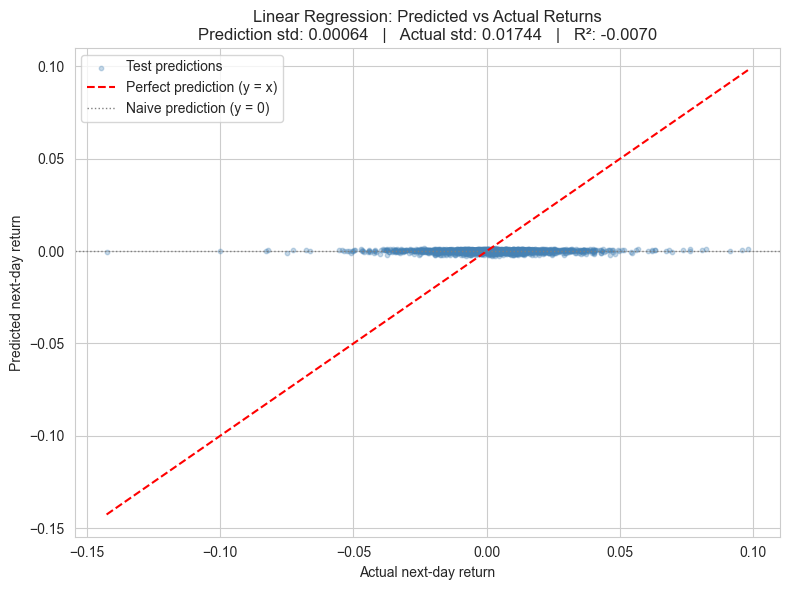

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter of test-set predictions vs truths
ax.scatter(y_reg_test, linreg_preds, alpha=0.3, s=10, color="steelblue", label="Test predictions")

# Reference line: perfect prediction would fall on y = x
lims = [y_reg_test.min(), y_reg_test.max()]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction (y = x)")

# Reference line: y = 0 (the "naive predict zero" baseline)
ax.axhline(0, color="gray", linestyle=":", linewidth=1, label="Naive prediction (y = 0)")

ax.set_xlabel("Actual next-day return")
ax.set_ylabel("Predicted next-day return")
ax.set_title(
    f"Linear Regression: Predicted vs Actual Returns\n"
    f"Prediction std: {linreg_preds.std():.5f}   |   Actual std: {y_reg_test.std():.5f}   |   R²: {linreg_r2:+.4f}"
)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 8. TimeSeriesSplit Cross-Validation

Evaluate both baseline models across 5 expanding-window folds of the training set.

For each model: **mean score +- standard deviation** across 5 folds. A small std (< 0.03) means stable performance; a large std (> 0.05) means regime-dependent, fragile performance.

### Critical methodology note
The 5 folds are constructed from the **training set only**. The outer test set (last 20%) remains untouched. No information flows from the test set into the CV process.

In [ ]:
# Set up 5-fold TimeSeriesSplit on the training set
tscv = TimeSeriesSplit(n_splits=5)

# Container to collect scores from each fold
logreg_cv_scores = {"accuracy": [], "macro_f1": []}
linreg_cv_scores = {"mae": [], "rmse": [], "r2": []}

print("Running 5-fold TimeSeriesSplit cross-validation...")
print("-" * 100)

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train_scaled), 1):
    # Slice the training set into fold-specific train and validation subsets
    X_fold_tr, X_fold_val   = X_train_scaled.iloc[tr_idx], X_train_scaled.iloc[val_idx]
    y_clf_fold_tr, y_clf_fold_val = y_clf_train.iloc[tr_idx], y_clf_train.iloc[val_idx]
    y_reg_fold_tr, y_reg_fold_val = y_reg_train.iloc[tr_idx], y_reg_train.iloc[val_idx]

    # Logistic Regression on this fold
    lr_clf = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
    lr_clf.fit(X_fold_tr, y_clf_fold_tr)
    lr_clf_preds = lr_clf.predict(X_fold_val)
    logreg_cv_scores["accuracy"].append(accuracy_score(y_clf_fold_val, lr_clf_preds))
    logreg_cv_scores["macro_f1"].append(f1_score(y_clf_fold_val, lr_clf_preds, average="macro"))

    # Linear Regression on this fold 
    lr_reg = LinearRegression()
    lr_reg.fit(X_fold_tr, y_reg_fold_tr)
    lr_reg_preds = lr_reg.predict(X_fold_val)
    linreg_cv_scores["mae"].append(mean_absolute_error(y_reg_fold_val, lr_reg_preds))
    linreg_cv_scores["rmse"].append(np.sqrt(mean_squared_error(y_reg_fold_val, lr_reg_preds)))
    linreg_cv_scores["r2"].append(r2_score(y_reg_fold_val, lr_reg_preds))

    # Log per-fold sizes and scores so we can see the expanding window
    print(f"Fold {fold}:  train size = {len(tr_idx):5d}   val size = {len(val_idx):5d}"
          f"   |   LogReg acc: {logreg_cv_scores['accuracy'][-1]:.4f}"
          f"   LinReg MAE: {linreg_cv_scores['mae'][-1]:.6f}")

print("-" * 100)

# Summarize: mean +- std across folds 
print("\nCROSS-VALIDATION SUMMARY\n")

print("Logistic Regression (classification):")
acc_mean, acc_std = np.mean(logreg_cv_scores["accuracy"]), np.std(logreg_cv_scores["accuracy"])
f1_mean, f1_std   = np.mean(logreg_cv_scores["macro_f1"]), np.std(logreg_cv_scores["macro_f1"])
print(f"  CV Accuracy:   {acc_mean:.4f} +- {acc_std:.4f}")
print(f"  CV Macro F1:   {f1_mean:.4f} +- {f1_std:.4f}")
print(f"  (Test set reference: accuracy = {logreg_acc:.4f}, macro F1 = {logreg_f1:.4f})")

print("\nLinear Regression (regression):")
mae_mean, mae_std   = np.mean(linreg_cv_scores["mae"]), np.std(linreg_cv_scores["mae"])
rmse_mean, rmse_std = np.mean(linreg_cv_scores["rmse"]), np.std(linreg_cv_scores["rmse"])
r2_mean, r2_std     = np.mean(linreg_cv_scores["r2"]), np.std(linreg_cv_scores["r2"])
print(f"  CV MAE:        {mae_mean:.6f} +- {mae_std:.6f}")
print(f"  CV RMSE:       {rmse_mean:.6f} +- {rmse_std:.6f}")
print(f"  CV R²:         {r2_mean:+.4f} +- {r2_std:.4f}")
print(f"  (Test set reference: MAE = {linreg_mae:.6f}, RMSE = {linreg_rmse:.6f}, R² = {linreg_r2:+.4f})")

Running 5-fold TimeSeriesSplit cross-validation...
----------------------------------------------------------------------------------------------------
Fold 1:  train size =  1650   val size =  1646   |   LogReg acc: 0.5049   LinReg MAE: 0.018175
Fold 2:  train size =  3296   val size =  1646   |   LogReg acc: 0.4927   LinReg MAE: 0.016534
Fold 3:  train size =  4942   val size =  1646   |   LogReg acc: 0.4994   LinReg MAE: 0.011692
Fold 4:  train size =  6588   val size =  1646   |   LogReg acc: 0.5146   LinReg MAE: 0.011933
Fold 5:  train size =  8234   val size =  1646   |   LogReg acc: 0.4921   LinReg MAE: 0.015363
----------------------------------------------------------------------------------------------------

CROSS-VALIDATION SUMMARY

Logistic Regression (classification):
  CV Accuracy:   0.5007 ± 0.0084
  CV Macro F1:   0.4987 ± 0.0066
  (Test set reference: accuracy = 0.5049, macro F1 = 0.5048)

Linear Regression (regression):
  CV MAE:        0.014739 +- 0.002553
  CV RMSE

### CV fold scores - stability across time windows

Plot each fold's validation score so we can see whether performance is stable (flat line) or regime-dependent (spiky line). The horizontal reference line shows the CV mean.

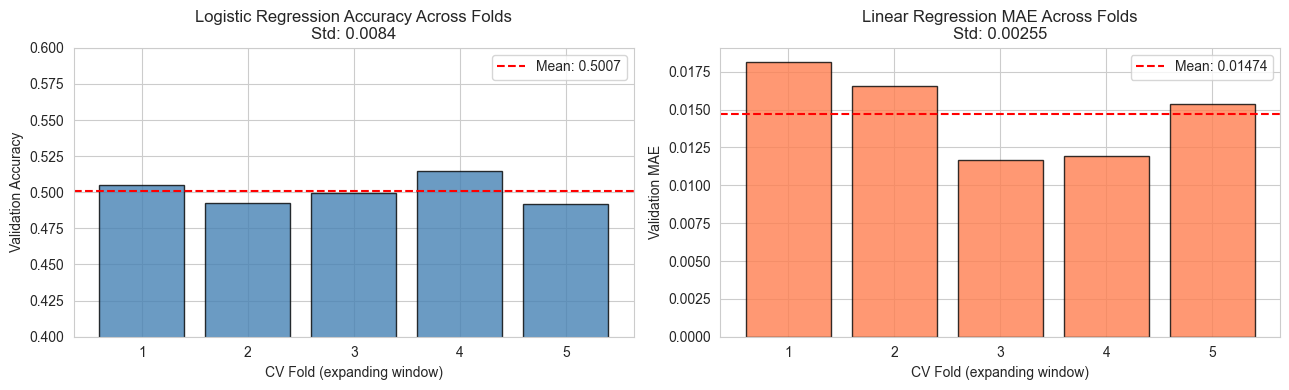

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

folds = list(range(1, 6))

# Left: Logistic Regression accuracy per fold 
axes[0].bar(folds, logreg_cv_scores["accuracy"], color="steelblue", alpha=0.8, edgecolor="black")
axes[0].axhline(np.mean(logreg_cv_scores["accuracy"]), color="red", linestyle="--",
                label=f"Mean: {np.mean(logreg_cv_scores['accuracy']):.4f}")
axes[0].set_xticks(folds)
axes[0].set_xlabel("CV Fold (expanding window)")
axes[0].set_ylabel("Validation Accuracy")
axes[0].set_title(f"Logistic Regression Accuracy Across Folds\nStd: {np.std(logreg_cv_scores['accuracy']):.4f}")
axes[0].set_ylim(0.40, 0.60)
axes[0].legend()

# Right: Linear Regression MAE per fold 
axes[1].bar(folds, linreg_cv_scores["mae"], color="coral", alpha=0.8, edgecolor="black")
axes[1].axhline(np.mean(linreg_cv_scores["mae"]), color="red", linestyle="--",
                label=f"Mean: {np.mean(linreg_cv_scores['mae']):.5f}")
axes[1].set_xticks(folds)
axes[1].set_xlabel("CV Fold (expanding window)")
axes[1].set_ylabel("Validation MAE")
axes[1].set_title(f"Linear Regression MAE Across Folds\nStd: {np.std(linreg_cv_scores['mae']):.5f}")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Save Results for Comparison

Save all metrics to a JSON file in `data/results/`. Phase 3 and beyond will load this file to build a growing comparison table across all models.

In [14]:
import json
from pathlib import Path

results_dir = Path("../data/results")
results_dir.mkdir(parents=True, exist_ok=True)

phase2_results = {
    "phase": 2,
    "phase_name": "baseline_models",

    "naive": {
        "classification": {
            "accuracy": float(naive_clf_acc),
            "macro_f1": float(naive_clf_f1),
        },
        "regression": {
            "mae":  float(naive_reg_mae),
            "rmse": float(naive_reg_rmse),
        },
    },

    "logistic_regression": {
        "test": {
            "accuracy":  float(logreg_acc),
            "precision": float(logreg_prec),
            "recall":    float(logreg_rec),
            "macro_f1":  float(logreg_f1),
        },
        "cv": {
            "accuracy_mean":  float(np.mean(logreg_cv_scores["accuracy"])),
            "accuracy_std":   float(np.std(logreg_cv_scores["accuracy"])),
            "macro_f1_mean":  float(np.mean(logreg_cv_scores["macro_f1"])),
            "macro_f1_std":   float(np.std(logreg_cv_scores["macro_f1"])),
            "n_folds": 5,
        },
    },

    "linear_regression": {
        "test": {
            "mae":  float(linreg_mae),
            "rmse": float(linreg_rmse),
            "r2":   float(linreg_r2),
        },
        "cv": {
            "mae_mean":  float(np.mean(linreg_cv_scores["mae"])),
            "mae_std":   float(np.std(linreg_cv_scores["mae"])),
            "rmse_mean": float(np.mean(linreg_cv_scores["rmse"])),
            "rmse_std":  float(np.std(linreg_cv_scores["rmse"])),
            "r2_mean":   float(np.mean(linreg_cv_scores["r2"])),
            "r2_std":    float(np.std(linreg_cv_scores["r2"])),
            "n_folds": 5,
        },
    },
}

results_file = results_dir / "phase2_baselines.json"
with open(results_file, "w") as f:
    json.dump(phase2_results, f, indent=2)

print(f"Saved: {results_file}")
print(f"File size: {results_file.stat().st_size} bytes")

Saved: ..\data\results\phase2_baselines.json
File size: 1160 bytes


## 10. Summary

- Established naive baselines for both tasks on the test set
- Fit Logistic Regression and Linear Regression on scaled features with a chronological 80/20 train/test split
- Validated with 5-fold TimeSeriesSplit CV on the training set only
- Saved all metrics to `data/results/phase2_baselines.json`
- Produced 4 visualizations: chronological split, confusion matrix comparison, predicted-vs-actual scatter, and CV stability bars

### Dataset split
- **Train:** 9,880 rows (2021-05-18 -> 2025-04-23) - UP rate 51.6%
- **Test:**  2,470 rows (2025-04-24 -> 2026-04-17) - UP rate 55.5%
- The 4-point higher UP rate on the test set reflects the 2025–2026 bullish regime

### Key findings

**Classification (Logistic Regression)**
- Test accuracy **0.5049** vs naive baseline **0.5547** - below naive on raw accuracy because the naive "always UP" strategy exploits the test-set UP majority
- Test macro F1 **0.5048** vs naive **0.3568** - The model learned to discriminate on BOTH classes rather than mimicking the majority
- Test DOWN recall **0.58** vs naive DOWN recall **0.00** - the model caught 638 of 1,100 DOWN days, the naive predictor caught zero
- CV accuracy **0.5007 +- 0.0084** - very stable across the 5 expanding-window folds, indicating the ~50% performance is a real, consistent property of the data, not a lucky split

**Regression (Linear Regression)**
- Test MAE **0.01232** vs naive **0.01234** - statistically indistinguishable
- Test RMSE **0.01750** vs naive **0.01751** - same story
- Test R² **-0.007** - essentially zero explanatory power; the model is no better than predicting the mean
- Prediction std **0.00064** vs actual std **0.01744** - a 27× collapse. The model defaulted to near-constant predictions because the linear signal is too weak to justify bolder bets
- CV MAE **0.01474 +- 0.00255** - higher variance across folds, reflecting that regression error depends on the validation period's volatility

### Interpretation
These results reproduce the well-established finding in quantitative finance that technical indicators carry near-zero linear predictive power on daily equity returns. The Logistic Regression's macro F1 improvement over naive is meaningful but modest, and Linear Regression offers no improvement over predicting the mean. This establishes the floor against which non-linear methods (Random Forest, XGBoost, LSTM) will be evaluated in subsequent phases.

### Next: Phase 3 - Ensemble Models
In `03_ensemble_models.ipynb` we move to non-linear methods: Random Forest for classification and XGBoost for regression - with hyperparameter tuning via `GridSearchCV` + `TimeSeriesSplit`.